Signal Sharpe (forecast_x_return): -0.562217733690626
Realized Sharpe (strategy_ret): -2.389047943236641
Correlation (signal vs realized): 0.8006033068618353


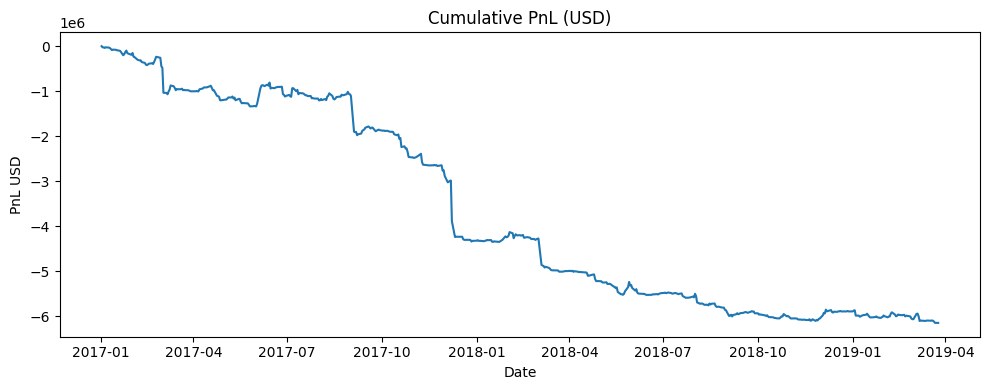

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the original RX file you uploaded earlier
df = pd.read_csv(r"C:\Users\loci_\Desktop\trading_webapp\DATA\all_input_files/RX1_small.csv")
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date").set_index("Date")

price = df["PX_CLOSE_1D"].astype(float)
stdev_price = df["st_dev"].astype(float)

# params
START_NAV_USD = 10_000_000
ANNUAL_VOL = 0.20
FX = 0.6485
tickValue = 10
tickSize = 0.01
MULT = tickValue / tickSize
LOOKBACK = 36
DECAY = 2 / (LOOKBACK + 1)

# returns
df["ret_net_for_var"] = price.diff()
df["ret_pct_for_sig"] = price.pct_change()

# variance with robust start
variance = [np.nan] * len(df)
ret_net = df["ret_net_for_var"].values
start_idx = None
for i, rn in enumerate(ret_net):
    if rn is not None and not np.isnan(rn) and rn != 0:
        start_idx = i
        break

if start_idx is not None:
    first_sq = ret_net[start_idx] ** 2
    variance[start_idx] = first_sq
    prev_var = first_sq
    for i in range(start_idx + 1, len(df)):
        rn = ret_net[i]
        rn2 = 0.0 if (rn is None or np.isnan(rn)) else rn * rn
        v = DECAY * rn2 + (1 - DECAY) * prev_var
        variance[i] = v
        prev_var = v

df["variance"] = variance
df["stdev_variance"] = np.sqrt(df["variance"])

# signal
df["ewma_fast"] = price.ewm(span=4, adjust=False).mean()
df["ewma_slow"] = price.ewm(span=16, adjust=False).mean()
df["raw_crossover"] = df["ewma_fast"] - df["ewma_slow"]
df["vol_adj_crossover"] = df["raw_crossover"] / df["stdev_variance"]
df["scaled_forecast"] = df["vol_adj_crossover"] * 7.5
df["capped_forecast"] = df["scaled_forecast"].clip(-20, 20)
df["forecast_x_return"] = df["capped_forecast"].shift(1) * df["ret_pct_for_sig"]

# sizing fixed bits
df["price_volatility"] = stdev_price / price * 100
df["one_pct_move"] = price * 0.01
df["block_value_eur"] = df["one_pct_move"] * MULT
df["icv_eur"] = df["price_volatility"] * df["block_value_eur"]
df["ivv"] = df["icv_eur"] / FX

# iterative loop with lagged NAV
nav_list = []
daily_cash_vol_list = []
target_contracts_list = []
trades_list = []
pnl_usd_list = []
carry_pnl_usd_list = []
trade_pnl_usd_list = []
carry_pnl_eur_list = []
trade_pnl_eur_list = []
strategy_ret_list = []

prev_nav = START_NAV_USD
prev_daily_cash_vol = prev_nav * ANNUAL_VOL / np.sqrt(256)
prev_target_contracts = 0

prices = price.values
ivv_vals = df["ivv"].values
caps = df["capped_forecast"].values

for i in range(len(df)):
    px_today = prices[i]
    px_yday = prices[i-1] if i > 0 else np.nan
    delta_price = px_today - px_yday if i > 0 else np.nan

    # lagged vol target
    daily_cash_vol_target = prev_daily_cash_vol

    # vol scaler
    ivv_today = ivv_vals[i]
    if np.isnan(ivv_today) or ivv_today == 0:
        vol_scaler_today = np.nan
    else:
        vol_scaler_today = daily_cash_vol_target / ivv_today

    cap_f = caps[i]
    if np.isnan(cap_f) or np.isnan(vol_scaler_today):
        subsystem_pos = 0.0
    else:
        subsystem_pos = (cap_f * vol_scaler_today) / 10.0

    target_contracts = int(round(subsystem_pos))
    trades = target_contracts - prev_target_contracts

    # carry pnl
    if i == 0 or np.isnan(delta_price):
        carry_pnl_eur = 0.0
    else:
        carry_pnl_eur = prev_target_contracts * delta_price * MULT

    # trade pnl
    if i == 0 or np.isnan(px_yday):
        trade_pnl_eur = 0.0
    else:
        trade_pnl_eur = trades * (px_yday - px_today) * MULT

    carry_pnl_usd = carry_pnl_eur / FX
    trade_pnl_usd = trade_pnl_eur / FX
    pnl_usd = carry_pnl_usd + trade_pnl_usd

    nav_today = prev_nav + pnl_usd
    strategy_ret = pnl_usd / prev_nav if prev_nav != 0 else 0.0

    # store
    nav_list.append(nav_today)
    daily_cash_vol_list.append(daily_cash_vol_target)
    target_contracts_list.append(target_contracts)
    trades_list.append(trades)
    pnl_usd_list.append(pnl_usd)
    carry_pnl_usd_list.append(carry_pnl_usd)
    trade_pnl_usd_list.append(trade_pnl_usd)
    carry_pnl_eur_list.append(carry_pnl_eur)
    trade_pnl_eur_list.append(trade_pnl_eur)
    strategy_ret_list.append(strategy_ret)

    # roll
    prev_nav = nav_today
    prev_daily_cash_vol = nav_today * ANNUAL_VOL / np.sqrt(256)
    prev_target_contracts = target_contracts

# assign back
df["nav_usd"] = nav_list
df["daily_cash_vol_target"] = daily_cash_vol_list
df["target_contracts"] = target_contracts_list
df["trades"] = trades_list
df["carry_pnl_eur"] = carry_pnl_eur_list
df["trade_pnl_eur"] = trade_pnl_eur_list
df["carry_pnl_usd"] = carry_pnl_usd_list
df["trade_pnl_usd"] = trade_pnl_usd_list
df["pnl_usd"] = pnl_usd_list
df["strategy_ret"] = strategy_ret_list

# cumulative pnl
df["cum_pnl_usd"] = df["pnl_usd"].cumsum()

# diagnostics: signal vs realized
signal = df["forecast_x_return"].dropna()
realized = df["strategy_ret"].replace([np.inf, -np.inf], np.nan).dropna()

if len(realized) > 0:
    # align lengths
    min_len = min(len(signal), len(realized))
    signal_al = signal.iloc[-min_len:]
    realized_al = realized.iloc[-min_len:]
    corr = np.corrcoef(signal_al, realized_al)[0, 1]
    sig_sharpe = signal_al.mean() / signal_al.std() * np.sqrt(252)
    strat_sharpe = realized_al.mean() / realized_al.std() * np.sqrt(252)
else:
    corr = np.nan
    sig_sharpe = np.nan
    strat_sharpe = np.nan

print("Signal Sharpe (forecast_x_return):", sig_sharpe)
print("Realized Sharpe (strategy_ret):", strat_sharpe)
print("Correlation (signal vs realized):", corr)

# plot cumulative pnl
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["cum_pnl_usd"])
plt.title("Cumulative PnL (USD)")
plt.xlabel("Date")
plt.ylabel("PnL USD")
plt.tight_layout()




=== Sharpe Attribution Summary ===
          Layer      Mean      Std    Sharpe
     Raw Signal -0.000964 0.027212 -0.562218
  Lagged Signal -0.000962 0.027236 -0.560748
   Vol-Targeted -0.000125 0.003524 -0.562218
Realized System -0.001584 0.010514 -2.391937

=== Correlation Matrix ===
                 Raw Signal  Lagged Signal  Vol-Targeted  Realized System
Raw Signal             1.00           0.03          1.00             0.80
Lagged Signal          0.03           1.00          0.03             0.06
Vol-Targeted           1.00           0.03          1.00             0.80
Realized System        0.80           0.06          0.80             1.00


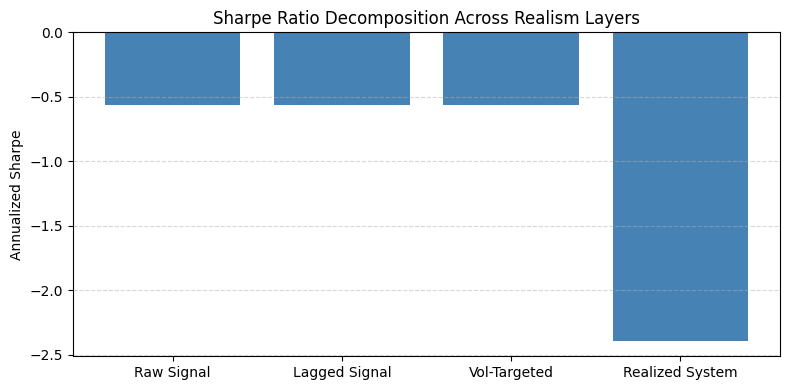

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the same file that already has forecasts etc.
df = pd.read_csv(r"C:\Users\loci_\Desktop\trading_webapp\DATA\gpt_output_rx1_full_chain_laggedNAV.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")

# 1️⃣ Ideal signal Sharpe (forecast[t-1] × return[t])
sig_raw = df["forecast_x_return"].replace([np.inf, -np.inf], np.nan).dropna()

# 2️⃣ Lagged signal (simulate next-day execution)
sig_lag = df["forecast_x_return"].shift(1).dropna()

# 3️⃣ Vol-targeted & capped signal (already embedded in capped_forecast)
# Convert capped forecast to directional exposure, normalize volatility
returns = df["PX_CLOSE_1D"].pct_change()
sig_volcap = (df["capped_forecast"].shift(1) / df["capped_forecast"].abs().shift(1).mean()) * returns
sig_volcap = sig_volcap.dropna()

# 4️⃣ Realized system (strategy_ret)
sig_real = df["strategy_ret"].replace([np.inf, -np.inf], np.nan).dropna()

# Helper: compute Sharpe
def sharpe(x):
    if len(x) < 2 or x.std() == 0:
        return np.nan
    return x.mean() / x.std() * np.sqrt(252)

# Compute stats
layers = {
    "Raw Signal": sig_raw,
    "Lagged Signal": sig_lag,
    "Vol-Targeted": sig_volcap,
    "Realized System": sig_real
}

results = []
for name, series in layers.items():
    results.append({
        "Layer": name,
        "Mean": series.mean(),
        "Std": series.std(),
        "Sharpe": sharpe(series)
    })

res_df = pd.DataFrame(results)

# Pairwise correlations (optional)
corr_df = pd.DataFrame({k: v for k, v in layers.items()}).corr()

print("\n=== Sharpe Attribution Summary ===")
print(res_df.to_string(index=False))
print("\n=== Correlation Matrix ===")
print(corr_df.round(2))

# Plot comparison
plt.figure(figsize=(8,4))
plt.bar(res_df["Layer"], res_df["Sharpe"], color="steelblue")
plt.title("Sharpe Ratio Decomposition Across Realism Layers")
plt.ylabel("Annualized Sharpe")
plt.grid(True, axis="y", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()
